# Inter-Layer Ablation — does widening the representation rescue depth?

Experiment 3 found that adding layers ($L$) barely helped, especially on the **binary** datasets:
each block passes the next layer only $m\times\text{cols\_per\_svm}$ columns, which for a binary
target is $m$ near-collinear decision scores — about one effective dimension, leaving depth nothing
to recompose. This ablation tests two structural fixes that widen the inter-layer representation:

- **skip**: carry the previous representation forward, $X_{\text{next}} = [\,\Phi W \;\|\; X_{\text{curr}}\,]$
- **phi_concat**: inject a compressed view of the feature map, $[\,\Phi W \;\|\; R(\Phi)\,]$
- **both**: concatenate all three
- **baseline**: unchanged (reproduces Experiment 3)

**The question:** does the **depth gain** (accuracy at best $L$ minus $L{=}1$, at fixed $m$) go from
$\approx 0$ under baseline to clearly positive under the fixes — on the binary datasets in particular?
That would show the architecture *can* learn deeper representations once the inter-layer bottleneck is removed.

In [3]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
pd.set_option("display.width",200); pd.set_option("display.max_columns",40)
mpl.rcParams.update({"figure.dpi":110,"font.size":10,"axes.grid":True,"grid.alpha":0.3})
CSV = "../results/exp_interlayer_ablation.csv"   # adjust path if needed

df = pd.read_csv(CSV)
df.columns=[c.strip() for c in df.columns]
for c in ["n_total","n_train","d","n_classes","m","L","P","seed","acc","macro_f1","train_time_s"]:
    if c in df: df[c]=pd.to_numeric(df[c],errors="coerce")
# primary metric: macro-F1 for multiclass when present, else accuracy
df["metric"]=np.where((df.task=="multiclass") & df.macro_f1.notna(), df.macro_f1, df.acc)

MODE_ORDER=[m for m in ["baseline","skip","phi_concat","both"] if m in df.interlayer_mode.unique()]
DS_ORDER=[d for d in ["HIGGS","SUSY","MiniBooNE","CoverType"] if d in df.dataset.unique()]
TASK=df.groupby("dataset").task.first().to_dict()
print("rows:",len(df))
print("modes:",MODE_ORDER)
print("datasets:",DS_ORDER, "| tasks:",TASK)
print("m:",sorted(df.m.dropna().unique().tolist())," L:",sorted(df.L.dropna().unique().tolist()))
print("n per dataset:",df.groupby("dataset").n_train.unique().to_dict())
df.head(3)

rows: 758
modes: ['baseline', 'skip', 'phi_concat', 'both']
datasets: ['HIGGS', 'SUSY', 'MiniBooNE', 'CoverType'] | tasks: {'CoverType': 'multiclass', 'HIGGS': 'binary', 'MiniBooNE': 'binary', 'SUSY': 'binary'}
m: [5, 10, 40]  L: [1, 2, 3]
n per dataset: {'CoverType': array([  5000, 100000]), 'HIGGS': array([  5000, 100000]), 'MiniBooNE': array([ 5000, 50000]), 'SUSY': array([  5000, 100000])}


,exp_id,dataset,task,interlayer_mode,n_total,n_train,n_test,d,n_classes,model,m,L,P,seed,acc,macro_f1,train_time_s,timestamp,metric
0,exp_interlayer_ablation,HIGGS,binary,baseline,5000,5000,20000,28,2,baseline_m5_L1,5,1,1000,0,0.6320,NaN,1.22,2026-06-20T02:13:53.860472,0.6320
1,exp_interlayer_ablation,HIGGS,binary,baseline,5000,5000,20000,28,2,baseline_m5_L2,5,2,1000,0,0.6256,NaN,1.97,2026-06-20T02:13:56.091853,0.6256
2,exp_interlayer_ablation,HIGGS,binary,baseline,5000,5000,20000,28,2,baseline_m5_L3,5,3,1000,0,0.6207,NaN,2.48,2026-06-20T02:13:59.013399,0.6207


## 1. Depth gain by mode — the headline

For each (dataset, mode, $m$, $n$): average over seeds, then take **best-$L$ minus $L{=}1$**.
If the fixes work, the binary datasets should move from $\approx 0$ (baseline) to positive (skip/both).

In [4]:
def seed_mean(keys):
    g=df.groupby(keys+["L"])["metric"].mean().reset_index()
    return g

A=df.groupby(["dataset","interlayer_mode","m","n_train","L"])["metric"].agg(["mean","std","size"]).reset_index()
A["std"]=A["std"].fillna(0.0)

def depth_gain_table():
    rows=[]
    for (ds,mode,m,n),g in A.groupby(["dataset","interlayer_mode","m","n_train"]):
        gg=g.set_index("L")["mean"]
        if 1 not in gg.index or len(gg)<2: continue
        bestL=gg.idxmax()
        # significance: gain beyond one seed std at best L
        std_bestL=g[g.L==bestL]["std"].iloc[0]
        gain=gg[bestL]-gg[1]
        rows.append(dict(dataset=ds,task=TASK[ds],mode=mode,m=int(m),n=int(n),
            L1=round(gg[1],4),bestL=int(bestL),bestL_val=round(gg[bestL],4),
            depth_gain=round(gain,4),sig=bool(gain>std_bestL)))
    return pd.DataFrame(rows)
DG=depth_gain_table()

print("=== mean depth gain by mode x task (the headline) ===")
piv=DG.pivot_table(index="mode",columns="task",values="depth_gain",aggfunc="mean").reindex(MODE_ORDER)
display(piv.round(4))
print("\n=== mean depth gain by mode x dataset ===")
piv2=DG.pivot_table(index="mode",columns="dataset",values="depth_gain",aggfunc="mean").reindex(MODE_ORDER)[DS_ORDER]
display(piv2.round(4))

=== mean depth gain by mode x task (the headline) ===


task,binary,multiclass
mode,,
baseline,0.0006,0.0550
skip,0.0035,0.0547
phi_concat,0.0018,0.0437
both,0.0028,0.0483



=== mean depth gain by mode x dataset ===


dataset,HIGGS,SUSY,MiniBooNE,CoverType
mode,,,,
baseline,0.0001,0.0000,0.0016,0.0550
skip,0.0042,0.0000,0.0064,0.0547
phi_concat,0.0015,0.0000,0.0039,0.0437
both,0.0037,0.0001,0.0045,0.0483


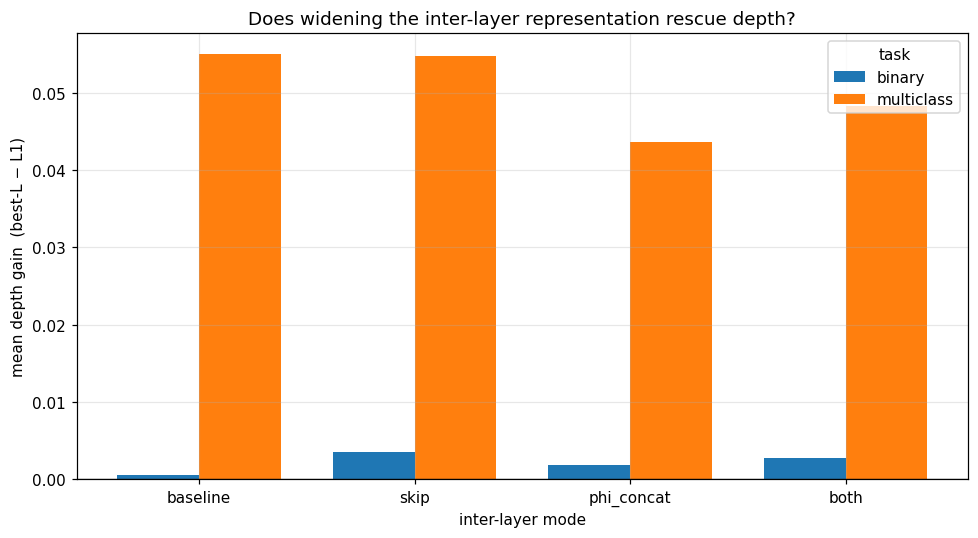

In [5]:
# Headline figure: depth gain by mode, binary vs multiclass (grouped bars)
fig,ax=plt.subplots(figsize=(9,5))
tasks=[t for t in ["binary","multiclass"] if t in DG.task.unique()]
x=np.arange(len(MODE_ORDER)); w=0.38
for i,t in enumerate(tasks):
    vals=[DG[(DG["mode"]==mo)&(DG.task==t)].depth_gain.mean() for mo in MODE_ORDER]
    ax.bar(x+(i-0.5)*w, vals, w, label=t)
ax.axhline(0,color="k",lw=.8)
ax.set_xticks(x); ax.set_xticklabels(MODE_ORDER)
ax.set_ylabel("mean depth gain  (best-L − L1)"); ax.set_xlabel("inter-layer mode")
ax.set_title("Does widening the inter-layer representation rescue depth?")
ax.legend(title="task")
plt.tight_layout(); plt.savefig("fig_ablation_depth_by_mode.png",bbox_inches="tight"); plt.show()

## 2. The depth curves themselves (binary focus)

The cleanest evidence: accuracy vs $L$ per mode on the **binary** datasets. Baseline should be flat or
declining; skip/both should rise with $L$. One panel per (dataset, $m$).

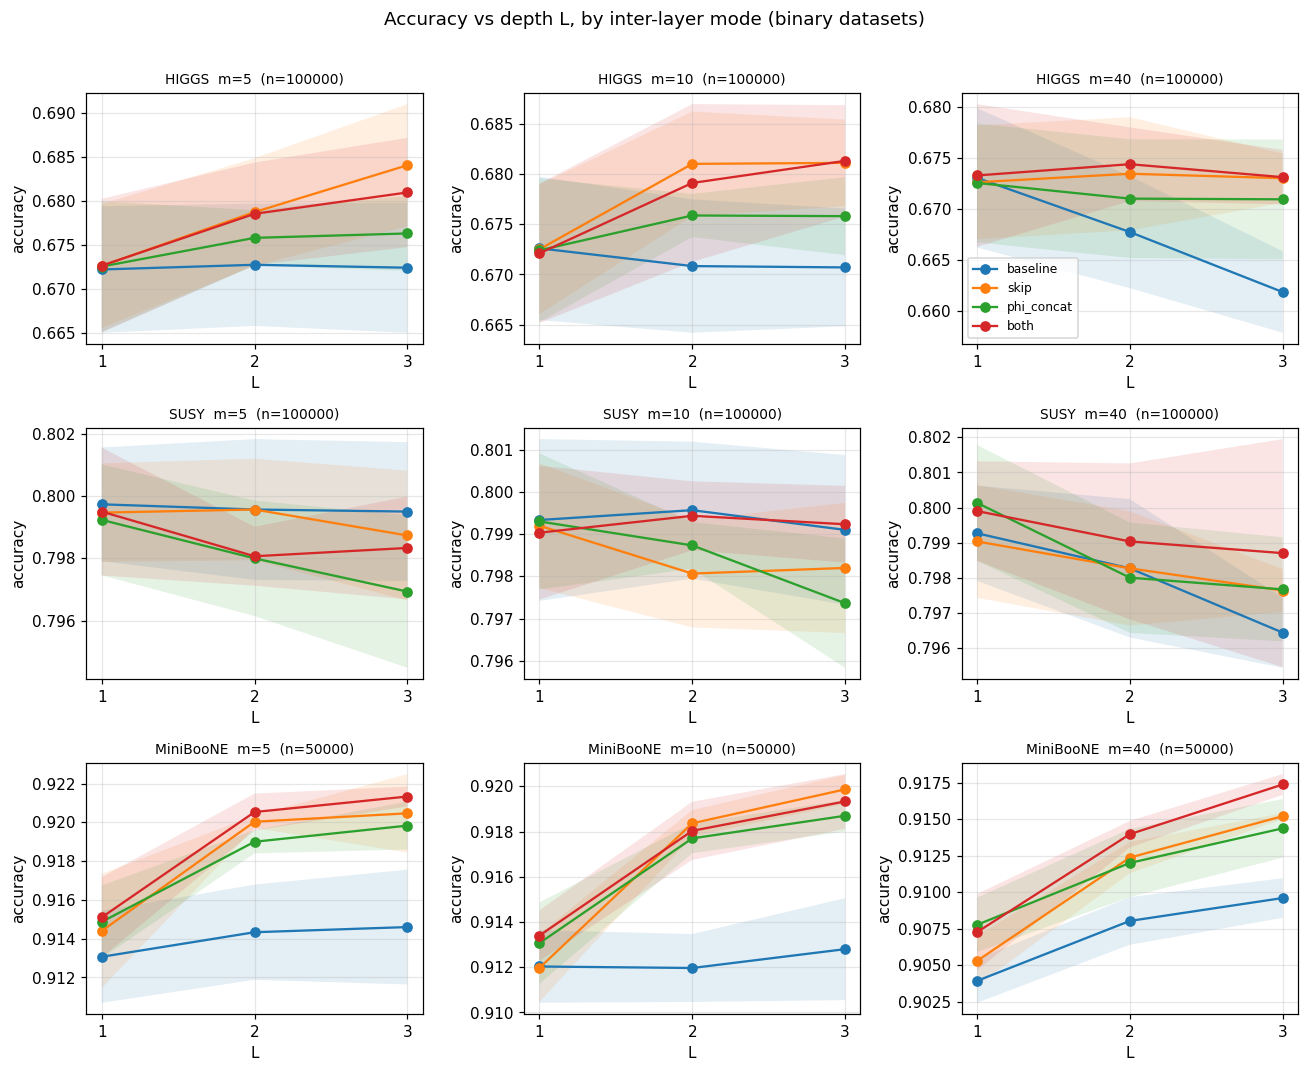

In [6]:
bin_ds=[d for d in DS_ORDER if TASK[d]=="binary"]
ms=sorted(df.m.dropna().unique().astype(int))
# pick the largest n per binary dataset (the regime where depth had nothing in Exp 3)
fig,axes=plt.subplots(len(bin_ds),len(ms),figsize=(4*len(ms),3.2*len(bin_ds)),squeeze=False)
for r,ds in enumerate(bin_ds):
    nmax=int(df[df.dataset==ds].n_train.max())
    for c,m in enumerate(ms):
        ax=axes[r][c]
        for mode in MODE_ORDER:
            g=A[(A.dataset==ds)&(A.interlayer_mode==mode)&(A.m==m)&(A.n_train==nmax)].sort_values("L")
            if g.empty: continue
            ax.plot(g.L,g["mean"],marker="o",label=mode)
            ax.fill_between(g.L,g["mean"]-g["std"],g["mean"]+g["std"],alpha=0.12)
        ax.set_title(f"{ds}  m={m}  (n={nmax})",fontsize=9)
        ax.set_xlabel("L"); ax.set_ylabel("accuracy"); ax.set_xticks(ms if False else [1,2,3])
axes[0][-1].legend(fontsize=8)
fig.suptitle("Accuracy vs depth L, by inter-layer mode (binary datasets)",y=1.01)
plt.tight_layout(); plt.savefig("fig_ablation_depth_curves.png",bbox_inches="tight"); plt.show()

## 3. Does depth now scale with width $m$? (the original hypothesis)

Experiment 3's $m=20$ plateau was measured under baseline. Here we ask whether, **under the fixes**,
the depth gain grows from $m{=}5\to10\to20$ — i.e. whether the depth$\times$width interaction appears
once the representation can use the extra columns.

mean depth gain by mode x m (binary only):


m,5,10,40
mode,,,
baseline,0.0003,0.0002,0.0019
skip,0.0036,0.0034,0.0036
phi_concat,0.0015,0.0019,0.0022
both,0.0024,0.0026,0.0037


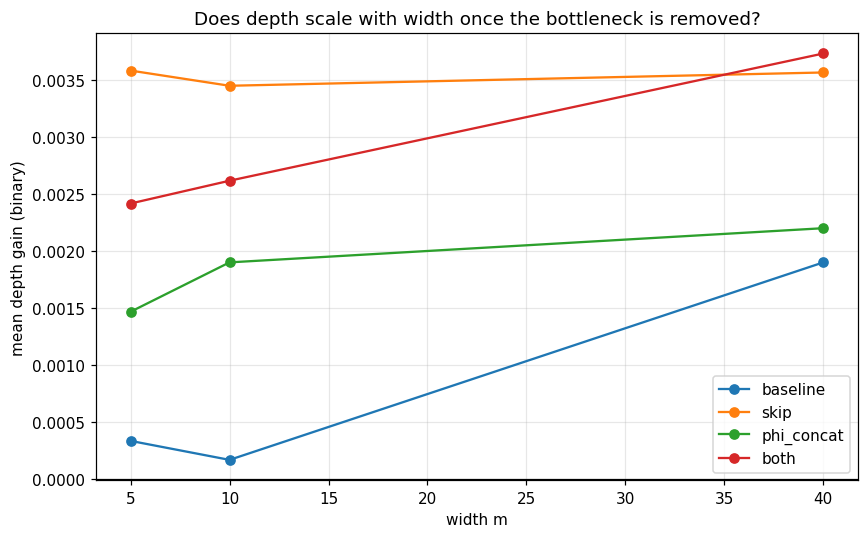

In [7]:
print("mean depth gain by mode x m (binary only):")
binDG=DG[DG.task=="binary"]
pm=binDG.pivot_table(index="mode",columns="m",values="depth_gain",aggfunc="mean").reindex(MODE_ORDER)
display(pm.round(4))

fig,ax=plt.subplots(figsize=(8,5))
for mode in MODE_ORDER:
    g=binDG[binDG["mode"]==mode].groupby("m").depth_gain.mean()
    ax.plot(g.index,g.values,marker="o",label=mode)
ax.axhline(0,color="k",lw=.8)
ax.set_xlabel("width m"); ax.set_ylabel("mean depth gain (binary)")
ax.set_title("Does depth scale with width once the bottleneck is removed?"); ax.legend()
plt.tight_layout(); plt.savefig("fig_ablation_depth_vs_m.png",bbox_inches="tight"); plt.show()

## 4. Separating the two effects: level shift vs depth slope

The fixes can help two ways: a **level shift** (better accuracy already at $L{=}1$, e.g. skip carrying
features forward) and a **depth slope** (gain from adding layers). The depth-rescue claim rests on the
*slope*. This table reports both so they are not conflated.

In [8]:
rows=[]
for ds in DS_ORDER:
    nmax=int(df[df.dataset==ds].n_train.max())
    base=A[(A.dataset==ds)&(A.interlayer_mode=="baseline")&(A.n_train==nmax)]
    for mode in MODE_ORDER:
        g=A[(A.dataset==ds)&(A.interlayer_mode==mode)&(A.n_train==nmax)]
        if g.empty or base.empty: continue
        # average over m for a compact summary
        L1=g[g.L==1]["mean"].mean()
        bestL=g.groupby("m").apply(lambda d: d.set_index("L")["mean"].max()).mean()
        base_L1=base[base.L==1]["mean"].mean()
        rows.append(dict(dataset=ds,task=TASK[ds],mode=mode,n=nmax,
            level_L1=round(L1,4), level_vs_base_L1=round(L1-base_L1,4),
            depth_slope=round(bestL-L1,4)))
LS=pd.DataFrame(rows)
print("Level shift (mode vs baseline at L=1) and depth slope (best-L − L1), at largest n:")
display(LS)

Level shift (mode vs baseline at L=1) and depth slope (best-L − L1), at largest n:


/tmp/ipykernel_5449/2818297763.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bestL=g.groupby("m").apply(lambda d: d.set_index("L")["mean"].max()).mean()
/tmp/ipykernel_5449/2818297763.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bestL=g.groupby("m").apply(lambda d: d.set_index("L")["mean"].max()).mean()
/tmp/ipykernel_5449/2818297763.py:10: DeprecationWarning: DataFrameGroupBy.apply operated 

,dataset,task,mode,n,level_L1,level_vs_base_L1,depth_slope
0,HIGGS,binary,baseline,100000,0.6726,0.0000,0.0002
1,HIGGS,binary,skip,100000,0.6726,-0.0000,0.0070
2,HIGGS,binary,phi_concat,100000,0.6725,-0.0001,0.0024
3,HIGGS,binary,both,100000,0.6727,0.0001,0.0062
4,SUSY,binary,baseline,100000,0.7994,0.0000,0.0001
5,SUSY,binary,skip,100000,0.7992,-0.0002,0.0000
6,SUSY,binary,phi_concat,100000,0.7996,0.0001,0.0000
7,SUSY,binary,both,100000,0.7995,0.0000,0.0001
8,MiniBooNE,binary,baseline,50000,0.9097,0.0000,0.0027
9,MiniBooNE,binary,skip,50000,0.9106,0.0009,0.0080


## 5. Best configuration vs Experiment-3 baseline

Bottom line for the thesis: does the best inter-layer mode beat the plain (baseline) architecture, and
by how much, per dataset? This is what would justify adopting a fix as an architectural choice.

In [9]:
rows=[]
for ds in DS_ORDER:
    for n in sorted(df[df.dataset==ds].n_train.unique()):
        g=A[(A.dataset==ds)&(A.n_train==n)]
        base=g[g.interlayer_mode=="baseline"]["mean"].max()
        best=g.loc[g["mean"].idxmax()]
        rows.append(dict(dataset=ds,task=TASK[ds],n=int(n),
            baseline_best=round(base,4),
            best_mode=best.interlayer_mode, best_m=int(best.m), best_L=int(best.L),
            best_val=round(best["mean"],4), improvement=round(best["mean"]-base,4)))
BEST=pd.DataFrame(rows)
print("Best inter-layer config vs baseline, per (dataset, n):")
display(BEST)
print("\nMean improvement of best mode over baseline by task:")
display(BEST.groupby("task").improvement.agg(["mean","max"]).round(4))

Best inter-layer config vs baseline, per (dataset, n):


,dataset,task,n,baseline_best,best_mode,best_m,best_L,best_val,improvement
0,HIGGS,binary,5000,0.6390,baseline,10,1,0.6390,0.0000
1,HIGGS,binary,100000,0.6730,skip,5,3,0.6841,0.0110
2,SUSY,binary,5000,0.7941,baseline,10,1,0.7941,0.0000
3,SUSY,binary,100000,0.7997,phi_concat,40,1,0.8001,0.0004
4,MiniBooNE,binary,5000,0.8982,skip,5,2,0.9016,0.0034
5,MiniBooNE,binary,50000,0.9146,both,5,3,0.9213,0.0067
6,CoverType,multiclass,5000,0.5904,both,10,3,0.5966,0.0062
7,CoverType,multiclass,100000,0.7548,skip,5,3,0.7682,0.0134



Mean improvement of best mode over baseline by task:


,mean,max
task,,
binary,0.0036,0.0110
multiclass,0.0098,0.0134


## 6. Reading guide (fill from the tables/figures)

- **§1 headline:** did binary depth gain go from $\approx0$ (baseline) to positive (skip/both)?
- **§2 curves:** are the skip/both accuracy-vs-$L$ lines rising where baseline is flat/declining?
- **§3 scaling:** under the fixes, does depth gain grow with $m$ (5→10→20)? (the Exp-3 plateau revisited)
- **§4 decomposition:** is the improvement a depth *slope*, or just a level shift at $L{=}1$? Both matter, report separately.
- **§5 bottom line:** does the best mode beat baseline enough to justify adopting it?

**Caveats:** report gains beyond one seed std (`sig` column); CoverType is the positive control
(depth already worked there — the fixes should not break it); distinguish "skip helps accuracy" from
"skip makes *depth* help", which is the actual claim.